# preRA cohort scRNA analysis in Python for Monocytes 
- CertPro

In [2]:
import glob
import os

import anndata
import h5py
import matplotlib
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as scs
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation

matplotlib.rcParams["pdf.fonttype"] = 42

In [3]:
# define some color patterns for plotting
nejm_color = [
    "#BC3C29FF",
    "#0072B5FF",
    "#E18727FF",
    "#20854EFF",
    "#7876B1FF",
    "#6F99ADFF",
    "#FFDC91FF",
    "#EE4C97FF",
]
jama_color = [
    "#374E55FF",
    "#DF8F44FF",
    "#00A1D5FF",
    "#B24745FF",
    "#79AF97FF",
    "#6A6599FF",
    "#80796BFF",
]

In [13]:
# define working path
data_path = "/home/workspace/data/ra_longitudinal/scrna/certPro/"
fig_path = "/home/workspace/data/ALTRA_manusript/figures/"
meta_path = "/home/workspace/github/ra-longitudinal/metadata/"
output_path = "/home/workspace/data/ra_longitudinal/output_results/cd16mono/"
# define a project name
proj_name = "RA_lg_converters_scRNA_mono_"
# sc.set_figure_params(fig_path)
sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [5]:
# set fig size
plt.rcParams["figure.figsize"] = [10, 8]

In [24]:
# define helper function
def save_plot(fig, ax, save):
    """
    Save a matplotlib figure to a file.

    Parameters:
    - fig: The matplotlib figure object to be saved.
    - ax: The matplotlib axes object associated with the figure.
    - save: The file path to save the figure to.

    Raises:
    - ValueError: If any of the input parameters are None.

    Returns:
    - None
    """
    if save is not None:
        if ax is not None:
            if fig is not None:
                fig.savefig(save, bbox_inches="tight")
            else:
                raise ValueError("fig is None, cannot save figure.")
        else:
            raise ValueError("ax is None, cannot save figure.")


def filter_limits(df, sign_limit=None, lFCs_limit=None):
    """
    Filter a DataFrame based on sign and log fold change limits.

    Parameters:
    df (DataFrame): The input DataFrame to be filtered.
    sign_limit (float, optional): The limit for p-values. Default is None.
    lFCs_limit (float, optional): The limit for log fold changes. Default is None.

    Returns:
    DataFrame: The filtered DataFrame based on the specified limits.
    """

    # Define limits if not defined
    if sign_limit is None:
        sign_limit = np.inf
    if lFCs_limit is None:
        lFCs_limit = np.inf

    # Filter by absolute value limits
    msk_sign = df["pvals"] < np.abs(sign_limit)
    msk_lFCs = np.abs(df["logFCs"]) < np.abs(lFCs_limit)
    df = df.loc[msk_sign & msk_lFCs]

    return df


def plot_volcano_df(
    data,
    x,
    y,
    top=5,
    genes=None,
    sign_thr=0.05,
    lFCs_thr=0.5,
    sign_limit=None,
    lFCs_limit=None,
    color_pos="#D62728",
    color_neg="#1F77B4",
    color_null="gray",
    figsize=(7, 5),
    dpi=100,
    ax=None,
    return_fig=False,
    save=None,
):
    """
    Plot logFC and p-values from a long formated data-frame.

    Parameters
    ----------
    data : pd.DataFrame
        Results of DEA in long format.
    x : str
        Column name of data storing the logFCs.
    y : str
        Columns name of data storing the p-values.
    top : int
        Number of top differentially expressed features to show.
    sign_thr : float
        Significance threshold for p-values.
    lFCs_thr : float
        Significance threshold for logFCs.
    sign_limit : float
        Limit of p-values to plot in -log10.
    lFCs_limit : float
        Limit of logFCs to plot in absolute value.
    color_pos: str
        Color to plot significant positive genes.
    color_neg: str
        Color to plot significant negative genes.
    color_null: str
        Color to plot rest of the genes.
    figsize : tuple
        Figure size.
    dpi : int
        DPI resolution of figure.
    ax : Axes, None
        A matplotlib axes object. If None returns new figure.
    return_fig : bool
        Whether to return a Figure object or not.
    save : str, None
        Path to where to save the plot. Infer the filetype if ending on {``.pdf``, ``.png``, ``.svg``}.

    Returns
    -------
    fig : Figure, None
        If return_fig, returns Figure object.
    """
    import numpy as np
    from adjustText import adjust_text

    # # Load plotting packages
    # plt = check_if_matplotlib()
    # at = check_if_adjustText()
    # Transform sign_thr
    sign_thr = -np.log10(sign_thr)

    # Extract df
    df = data.copy()
    df["logFCs"] = df[x]
    df["pvals"] = -np.log10(df[y])

    # Filter by limits
    df = filter_limits(df, sign_limit=sign_limit, lFCs_limit=lFCs_limit)

    # Define color by up or down regulation and significance
    df["weight"] = color_null
    up_msk = (df["logFCs"] >= lFCs_thr) & (df["pvals"] >= sign_thr)
    dw_msk = (df["logFCs"] <= -lFCs_thr) & (df["pvals"] >= sign_thr)
    df.loc[up_msk, "weight"] = color_pos
    df.loc[dw_msk, "weight"] = color_neg

    # Plot
    fig = None
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    df.plot.scatter(x="logFCs", y="pvals", c="weight", sharex=False, ax=ax)
    ax.set_axisbelow(True)

    # Draw sign lines
    ax.axhline(y=sign_thr, linestyle="--", color="black")
    ax.axvline(x=lFCs_thr, linestyle="--", color="black")
    ax.axvline(x=-lFCs_thr, linestyle="--", color="black")

    if genes is None:
        # Plot top sign features
        signs = df[up_msk | dw_msk].sort_values("pvals", ascending=False)
        signs = signs.iloc[:top]
    else:
        signs = df[up_msk | dw_msk].sort_values("pvals", ascending=False)
        signs = signs.loc[signs.index.isin(genes)]
    # Add labels
    ax.set_ylabel("-log10(p.adj)")
    ax.set_xlabel("Log2 fold change")
    texts = []
    for x, y, s in zip(signs["logFCs"], signs["pvals"], signs.index):
        texts.append(ax.text(x, y, s))
    if len(texts) > 0:
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color="black"), ax=ax)

    save_plot(fig, ax, save)

    if return_fig:
        return fig


# define helper function
def get_marker_expression_stats(adata, markers, cluster_col):
    """
    Calculate mean expression and percent expressing cells for given markers per cluster.

    Parameters
    ----------
    adata : AnnData
        AnnData object with expression data.
    markers : list of str
        List of marker gene names.
    cluster_col : str
        Column in adata.obs to group by (e.g., cluster label).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: cluster_col, gene, mean_expression, percent_expressing
    """
    # Check if cluster_col exists in adata.obs
    if cluster_col not in adata.obs.columns:
        raise ValueError(
            f"'{cluster_col}' not found in adata.obs columns: {list(adata.obs.columns)}"
        )

    # Extract marker expression and cluster info into a DataFrame
    df = sc.get.obs_df(adata, keys=markers + [cluster_col])

    # Define percent expressing function
    def percent_expressing(x):
        return np.mean(x > 0) * 100

    # Aggregate: get mean and percent expressing for each marker per cluster
    agg_df = (
        df.groupby(cluster_col)[markers].agg([percent_expressing, "mean"]).reset_index()
    )

    # If cluster_col is not a column, reset index to make it a column
    if cluster_col not in agg_df.columns:
        agg_df = agg_df.reset_index()

    # Reshape to tidy format:
    # - set cluster_col as index
    # - melt to long format
    # - rename columns for clarity
    # - pivot so each row is cluster/gene, columns are metrics
    result = (
        agg_df.set_index(cluster_col)
        .melt(value_name="value", ignore_index=False)
        .rename(columns={"variable_0": "gene", "variable_1": "metric"})
        .reset_index()
        .pivot(index=[cluster_col, "gene"], columns="metric", values="value")
        .reset_index()
    )

    # Rename columns for clarity
    result = result.rename(
        columns={"mean": "mean_expression", "percent_expressing": "percent_expressing"}
    )

    # Remove index name if present
    result.index.name = None

    return result

# load data

In [ ]:
# load the deep clean data
joint_adata_fl = sc.read_h5ad(
    "/home/workspace/data/ra_longitudinal/scrna/certPro/ALTRA_certPro_scRNA_141_samples_combined_adata.h5ad"
)

In [ ]:
joint_adata_fl.obs["sample.sampleKitGuid"].unique

In [ ]:
# subset the monocytes
joint_adata_fl.obs.loc[
    joint_adata_fl.obs["AIFI_L3_new"].str.contains("monocyte"), "AIFI_L3_new"
].unique()

In [ ]:
# subset aim3 data
aim3_meta = pd.read_csv(
    meta_path + "ALTRA_RA_Aim3_ALTRA_converters_longitudinal_scrna_metadata.csv"
)
aim3_meta.columns

In [ ]:
# subset the monocytes in aim3
mono_adata = joint_adata_fl[
    (joint_adata_fl.obs["AIFI_L3_new"].str.contains("monocyte"))
].copy()

In [ ]:
mono_adata

## Rerun basic normalization

In [ ]:
mono_adata.obs["sample.sampleKitGuid"].unique()

In [ ]:
# save the raw counts
mono_adata.layers["counts"] = mono_adata.X.copy()

In [ ]:
# mitochondrial genes
mono_adata.var["mt"] = mono_adata.var_names.str.startswith("MT-")
# ribosomal genes
mono_adata.var["ribo"] = mono_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
mono_adata.var["hb"] = mono_adata.var_names.str.contains(("^HB[^(P)]"))
sc.pp.calculate_qc_metrics(
    mono_adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

In [ ]:
# cpm normalization
sc.pp.normalize_total(mono_adata, target_sum=1e4, inplace=True)
sc.pp.log1p(mono_adata)

In [ ]:
# %%time
sc.pp.highly_variable_genes(mono_adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

In [ ]:
mono_adata.raw = mono_adata

In [ ]:
mono_adata.raw.X

In [ ]:
sc.pp.scale(mono_adata, max_value=10)

In [ ]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(mono_adata, svd_solver="arpack", use_highly_variable=True)

In [ ]:
sc.pl.pca_scatter(mono_adata, color=["pct_counts_ribo", "pct_counts_mt"])

In [ ]:
# # setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
# sc.pp.pca(mono_adata, svd_solver="arpack", use_highly_variable=True)

In [ ]:
# plot the principle component variance explained
sc.pl.pca_variance_ratio(mono_adata, log=True)

In [ ]:
sc.pp.neighbors(mono_adata, n_neighbors=10, n_pcs=20, use_rep="X_pca")
sc.tl.umap(mono_adata)

In [ ]:
# save the pre-harmonaized umap
mono_adata.obsm["X_orignial_umap"] = mono_adata.obsm["X_umap"].copy()

In [ ]:
mono_adata

In [ ]:
# run harmony
import scanpy.external as sce

sce.pp.harmony_integrate(
    mono_adata,
    ["file.batchID", "subject.biologicalSex"],
    adjusted_basis="X_pca_harmony",
)
sc.pp.neighbors(mono_adata, n_neighbors=30, n_pcs=20, use_rep="X_pca_harmony")
sc.tl.umap(mono_adata)
mono_adata.obsm["X_harmony_umap"] = mono_adata.obsm["X_umap"].copy()

In [ ]:
# sc.pp.neighbors(mono_adata, n_neighbors=10, n_pcs=30, use_rep='X_pca_harmony',key_added='harmony_neighbors')
# sc.tl.umap(mono_adata, neighbors_key='harmony_neighbors')
# sc.tl.leiden(mono_adata, key_added="leiden_0_5", resolution=0.5, neighbors_key='harmony_neighbors')

### run TSNE

In [ ]:
# from openTSNE import TSNE
# tsne = TSNE(
#     perplexity=30,
#     metric="euclidean",
#     n_jobs=58,
#     random_state=42,
#     verbose=True,
# )

In [ ]:
# %%time
# embedding_train = tsne.fit(mono_adata.obsm['X_pca_harmony'])

In [ ]:
# sc.pp.neighbors(mono_adata, n_neighbors=10, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.tsne(mono_adata, use_rep="X_pca_harmony")

In [ ]:
mono_adata.obsm["X_pca_harmony"]

In [ ]:
# mono_adata.obsm['X_harmony_umap'] = mono_adata.obsm['X_umap'].copy()

In [ ]:
sc.pl.pca_loadings(mono_adata, components="1,2,3")

In [ ]:
# run clusters
sc.tl.leiden(mono_adata, key_added="leiden_0_5", resolution=0.5)

In [ ]:
# run clusters
sc.tl.leiden(mono_adata, key_added="leiden_1", resolution=1, n_iterations=2)

In [ ]:
# run clusters
sc.tl.leiden(mono_adata, key_added="leiden_1_2", resolution=1.2, n_iterations=2)

In [ ]:
mono_adata

In [ ]:
sc.pl.umap(
    mono_adata,
    color=[
        "file.batchID",
        "subject.subjectGuid",
        "leiden_0_5",
        "subject.biologicalSex",
        "AIFI_L2",
        "AIFI_L3_new",
    ],
    ncols=3,
    legend_loc="on data",
    wspace=0.4,
    save=proj_name + "_rna_hamony_umap.png",
)

In [ ]:
# sc.pl.embedding(
#     mono_adata, basis='X_orignial_umap',
#     color=['file.batchID',  "subject.subjectGuid", 'leiden_0_5',
#            'subject.biologicalSex', 'AIFI_L2', 'AIFI_L3_new'],
#     ncols=3, legend_loc = 'on data',
#     wspace=0.4,
#     save=  proj_name+'_rna_umap.png'
# )

In [ ]:
# save data
mono_adata.write_h5ad(data_path + "ALTRA_scRNA_all_monocytes_certPro.h5ad")

### upload data to HISE

In [3]:
import hisepy as hp

In [9]:
# upload file to hise
hp.upload.upload_files(
    files=[
        "/home/workspace/data/ALTRA_manusript/ALTRA_scRNA_all_monocytes_certPro.h5ad"
    ],
    study_space_id="223de760-9624-45bd-aefe-ca24c75b1800",
    title="AlTRA scRNA all monocytes h5ad object",
    input_file_ids=["609f7543-d4d5-41e9-a3d2-8e50c3e7c61d"],
    destination="scRNA",
)

{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': '5731f884-7815-4388-af59-e1cf9da36fac',
 'ProcessId': 'b0cfe10b-666c-4ef9-99a6-4a5809697e41',
 'WorkflowId': 'e408d1a8-548b-4014-90cc-f9976faa880a',
 'FileIds': ['693c6b98-31f4-478f-9e38-0f42c35b2263']}

## check expression

In [9]:
hp.cache_files(["f85270d8-5d91-4aa6-b8eb-887bd64e1f9e"])

In [ ]:
# load the dataset
mono_adata = sc.read_h5ad(data_path + "ALTRA_scRNA_all_monocytes_certPro.h5ad")

In [ ]:
mono_adata

In [ ]:
# sc.pl.umap(
#     mono_adata,
#     color=['file.batchID',  "subject.subjectGuid", 'leiden_0_5',
#            'subject.biologicalSex', 'AIFI_L2', 'AIFI_L3'],
#     ncols=3,
#     wspace=0.4,
#     save=  proj_name+'_rna_hamony_umap.png'
# )

In [ ]:
with plt.rc_context({"figure.figsize": (8, 8), "figure.dpi": (100)}):
    sc.pl.umap(
        mono_adata,
        color=["leiden_1", "AIFI_L3_new"],
        legend_loc="on data",
        ncols=2,
        save=proj_name + "_rna_hamony_umap_leiden_1.png",
    )

In [ ]:
sc.pl.umap(
    mono_adata,
    color=["TNF", "IL1B"],
    vmin="p1",
    vmax="p99",
    frameon=False,
    save=proj_name + "_rna_hamony_umap_TNF.png",
)

In [ ]:
sc.tl.embedding_density(mono_adata, basis="umap", groupby="status")

In [ ]:
sc.pl.embedding_density(mono_adata, basis="umap", key="umap_density_status")

In [ ]:
mono_adata

In [ ]:
sc.pl.embedding(
    mono_adata,
    color=["AIFI_L3_new", "leiden_1"],
    legend_loc="on data",
    basis="X_orignial_umap",
    frameon=False,
    ncols=2,
    save=proj_name + "_celltype_leiden_1.pdf",
)

In [ ]:
sc.pl.embedding(
    mono_adata,
    color=["AIFI_L3_new", "leiden_1", "leiden_1_2", "leiden_0_5"],
    legend_loc="on data",
    basis="X_tsne",
    frameon=False,
    ncols=2,
    save=proj_name + "_celltype_leiden_1.pdf",
)

In [ ]:
sc.pl.embedding(
    mono_adata,
    color=["AIFI_L3_new", "leiden_1"],
    legend_loc="on data",
    basis="X_tsne",
    frameon=False,
    ncols=2,
    save=proj_name + "_celltype_leiden_1.pdf",
)

In [ ]:
sc.tl.embedding_density(mono_adata, basis="tsne", groupby="status")

In [ ]:
sc.pl.embedding_density(mono_adata, basis="tsne", key="tsne_density_status")

In [ ]:
mono_adata.obs["AIFI_L3_new"].unique()

In [ ]:
sc.pl.dotplot(
    mono_adata,
    ["TNF", "IL1B", "IL6", "CCR2", "CD14", "FCGR3A", "HLA-DRA"],
    "pred_manual",
    save=proj_name + "_rna_TNF_dotpolt.png",
    dendrogram=True,
)

In [ ]:
sc.pl.dotplot(
    mono_adata,
    ["TNF", "IL1B", "IL1RN", "CCR2", "CD14", "FCGR3A"],
    "pred_manual",
    standard_scale="var",
    save=proj_name + "_rna_TNF_dotpolt.png",
    dendrogram=True,
)

# Analyze expression in paired comparison

In [ ]:
# load pair metadata
pair_meta = pd.read_csv(
    "/home/workspace/data/ra_longitudinal/output_results/"
    + "AIM3_paired_pre_post_conversion_samples.csv"
)
pair_meta.head()

In [ ]:
# subset the expression in paired comparison
pair_mono_adata = mono_adata[
    mono_adata.obs["sample.sampleKitGuid"].isin(pair_meta["sample.sampleKitGuid"])
].copy()
pair_mono_adata

In [ ]:
pair_mono_adata.obs[["n_umis", "total_counts"]]

In [ ]:
# add status
pair_mono_adata.obs.drop(columns="status", inplace=True)
pair_mono_adata.obs = pair_mono_adata.obs.merge(
    pair_meta[["sample.sampleKitGuid", "status"]], how="left", on="sample.sampleKitGuid"
)
pair_mono_adata

In [ ]:
# load data
pair_mono_adata = sc.read_h5ad(data_path + "ALTRA_scRNA_monocytes_paired_certPro.h5ad")

In [ ]:
# pair_meta[['sample.sampleKitGuid','status']]

In [ ]:
pair_mono_adata.obs["AIFI_L3_new"].value_counts()

In [ ]:
pair_mono_adata.obs["celltype_status"] = pair_mono_adata.obs["AIFI_L3_new"].astype(
    "str"
) + pair_mono_adata.obs["status"].astype("str")

In [ ]:
sc.pl.dotplot(
    pair_mono_adata,
    ["TNF", "IL1B", "IL1RN", "CCR2", "CD14", "FCGR3A"],
    "celltype_status",
    standard_scale="var",
    save=proj_name + "_paired_samples_rna_TNF_dotpolt.png",
    dendrogram=True,
)

In [ ]:
pair_mono_adata

In [ ]:
sc.pl.dotplot(
    pair_mono_adata,
    ["TNF", "IL1B", "IL1RN", "CCR2", "CD14", "FCGR3A"],
    "celltype_status",
    standard_scale="var",
    save=proj_name + "_paired_samples_rna_TNF_dotpolt_status.png",
    dendrogram=True,
)

In [ ]:
# plot the markers gene list from the paper
gene_list = [
    "NFKBIA",
    "TNF",
    "IL1B",
    "CCL3",
    "CCL4",
    "ICAM1",
    "FOLR2",
    "CD14",
    "FCGR3A",
    "KLF6",
    "NR4A1",
    "DUSP1",
    "ATF3",
]

sc.pl.dotplot(
    pair_mono_adata,
    gene_list,
    "AIFI_L3",
    standard_scale="var",
    swap_axes=True,
    save=proj_name + "_AIFI_L3_target_genes.pdf",
)

In [ ]:
with plt.rc_context({"figure.figsize": (8, 4)}):
    sc.pl.violin(
        pair_mono_adata,
        ["TNF"],
        groupby="AIFI_L3",
        save=proj_name + "_rna_TNF_violin.png",
        inner="box",
        rotation=90,
    )

In [ ]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(pair_mono_adata, svd_solver="arpack", use_highly_variable=True)
# plot the principle component variance explained
sc.pl.pca_variance_ratio(pair_mono_adata, log=True)

In [ ]:
pair_mono_adata

In [ ]:
sc.pl.embedding(
    pair_mono_adata,
    color=["AIFI_L3_new", "leiden_1"],
    legend_loc="on data",
    basis="X_tsne",
    frameon=False,
    ncols=2,
    save=proj_name + "_paired_leiden_1.pdf",
)

In [ ]:
# set order for status column
pair_mono_adata.obs["status"] = pair_mono_adata.obs["status"].astype("str")
pair_mono_adata.obs.loc[pair_mono_adata.obs["status"] == "pre_conv", "status"] = (
    "pre-disease"
)
pair_mono_adata.obs["status"] = (
    pair_mono_adata.obs["status"]
    .astype("category")
    .cat.reorder_categories(["pre-disease", "conversion"], ordered=True)
)

In [ ]:
sc.tl.embedding_density(pair_mono_adata, basis="tsne", groupby="status")

In [ ]:
sc.set_figure_params(scanpy=True, fontsize=14)
sc.pl.embedding_density(
    pair_mono_adata,
    basis="tsne",
    key="tsne_density_status",
    ncols=2,
    color_map="magma",
    save=proj_name + "_paired_tsne_density_status.pdf",
)

In [ ]:
sc.pl.embedding(
    pair_mono_adata,
    color=["status", "leiden_1", "AIFI_L3_new"],  # legend_loc='on data',
    basis="X_tsne",
    save=proj_name + "_paired_status.png",
)

In [ ]:
with plt.rc_context({"figure.figsize": (4, 4), "figure.dpi": (400)}):
    ax = sc.pl.embedding(
        pair_mono_adata,
        color=["AIFI_L3_new"],  # legend_loc='on data',
        legend_fontsize="small",
        frameon=False,
        basis="X_tsne",
        save=proj_name + "_paired_AIFI_L3_new.pdf",
    )

In [ ]:
sc.pl.embedding(
    pair_mono_adata,
    color=["leiden_1"],
    legend_loc="on data",
    frameon=False,
    basis="X_tsne",
    save=proj_name + "_paired_leiden_1.pdf",
)

In [ ]:
sc.pl.embedding(
    pair_mono_adata,
    color=["TNF", "IL1B", "CCL3", "NFKBIA"],  # legend_loc='on data',
    basis="X_tsne",
    vmin="p1",
    vmax="p99",
    frameon=False,
    ncols=2,
    save=proj_name + "_marker_genes.png",
)

In [ ]:
sc.pl.violin(
    pair_mono_adata,
    ["TNF"],
    groupby="AIFI_L3",
    rotation=90,
    save=proj_name + "TNF_violinplot.png",
)

In [ ]:
pair_mono_adata

In [ ]:
# save data
pair_mono_adata.write_h5ad(data_path + "ALTRA_scRNA_monocytes_paired_certPro.h5ad")

### analyze the clusters

In [10]:
hp.cache_files(["b69cc4c1-3f35-4c76-8730-b6a8004004f5"])

['/home/workspace/input/569004694/UCSDCU_Y4/b69cc4c1-3f35-4c76-8730-b6a8004004f5/ALTRA_scRNA_monocytes_paired_certPro.h5ad']

In [34]:
# load data
pair_mono_adata = sc.read_h5ad(
    "/home/workspace/input/569004694/UCSDCU_Y4/b69cc4c1-3f35-4c76-8730-b6a8004004f5/ALTRA_scRNA_monocytes_paired_certPro.h5ad"
)

In [36]:
pair_mono_adata

AnnData object with n_obs × n_vars = 51025 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'Sta

### plot Fig 2G

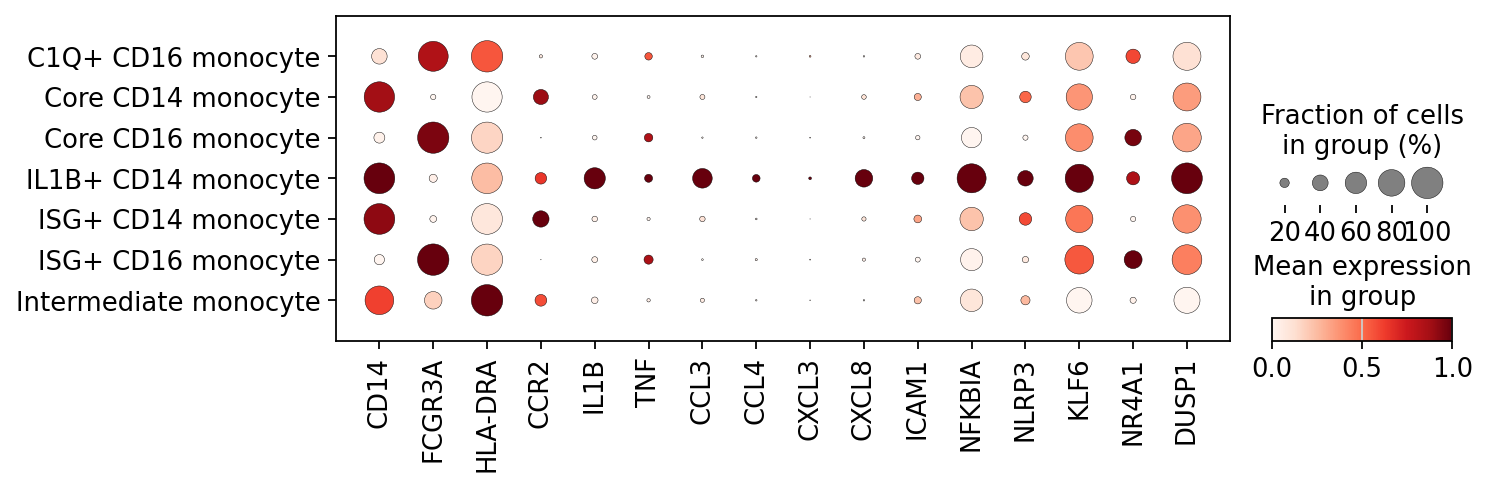

In [14]:
gene_list = [
    "CD14",
    "FCGR3A",
    "HLA-DRA",
    "CCR2",
    "IL1B",
    "TNF",
    "CCL3",
    "CCL4",
    "CXCL3",
    "CXCL8",
    "ICAM1",
    "NFKBIA",
    "NLRP3",
    "KLF6",
    "NR4A1",
    "DUSP1",
]
cm = 1 / 2.54  # centimeters in inches

dp = sc.pl.dotplot(
    pair_mono_adata,
    gene_list,
    "AIFI_L3",
    standard_scale="var",
    figsize=[10.73 / 1.2, 3.21 / 1.2],
    #  return_fig=True,
    save=proj_name + "_paired_samples_AIFI_L3.pdf",
    dendrogram=False,
)

## Fig S5H compare gex of IL1b monocyte VS core CD14 monocyte

In [15]:
pair_mono_adata.obs["AIFI_L3"].unique()

['C1Q+ CD16 monocyte', 'IL1B+ CD14 monocyte', 'Intermediate monocyte', 'Core CD14 monocyte', 'Core CD16 monocyte', 'ISG+ CD16 monocyte', 'ISG+ CD14 monocyte']
Categories (7, object): ['C1Q+ CD16 monocyte', 'Core CD14 monocyte', 'Core CD16 monocyte', 'IL1B+ CD14 monocyte', 'ISG+ CD14 monocyte', 'ISG+ CD16 monocyte', 'Intermediate monocyte']

In [21]:
# test for top genes that seperate the cells
cluster_name = "AIFI_L3"
sc.tl.rank_genes_groups(
    pair_mono_adata,
    groupby=cluster_name,
    groups=["IL1B+ CD14 monocyte"],
    reference="Core CD14 monocyte",
    method="wilcoxon",
    key_added="wilcoxon_il1b_vs_core_cd14",
)

In [16]:
il1bvscore_cd14_degs = sc.get.rank_genes_groups_df(
    pair_mono_adata, key="wilcoxon_il1b_vs_core_cd14", pval_cutoff=0.05, group=None
)
il1bvscore_cd14_degs = il1bvscore_cd14_degs.reindex(
    il1bvscore_cd14_degs["pvals_adj"].sort_values(ascending=True).index
)
il1bvscore_cd14_degs.to_csv(
    output_path + proj_name + cluster_name + "_il1bvscore_cd14_wilcoxon_sig_degs.csv"
)

In [ ]:
cluster_name = "AIFI_L3"
il1bvscore_cd14_degs = pd.read_csv(
    output_path + proj_name + cluster_name + "_il1bvscore_cd14_wilcoxon_sig_degs.csv"
)

In [17]:
il1bvscore_cd14_degs = il1bvscore_cd14_degs.set_index("names")
il1bvscore_cd14_degs

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
BTG2,36.729961,2.686426,2.428947e-295,8.146201e-291
ZFP36,35.656673,1.831412,1.856960e-278,3.113936e-274
NAMPT,34.046059,2.431517,4.641935e-254,5.189374e-250
EGR1,32.233856,2.667222,5.923545e-228,4.966597e-224
NFKBIA,30.463043,1.924873,8.048464e-204,5.398587e-200
...,...,...,...,...
IRAK3,3.255329,0.206711,1.132612e-03,4.826624e-02
CD302,-3.253812,-0.186782,1.138678e-03,4.846316e-02
SIRPB1,-3.253400,-0.299229,1.140329e-03,4.847193e-02


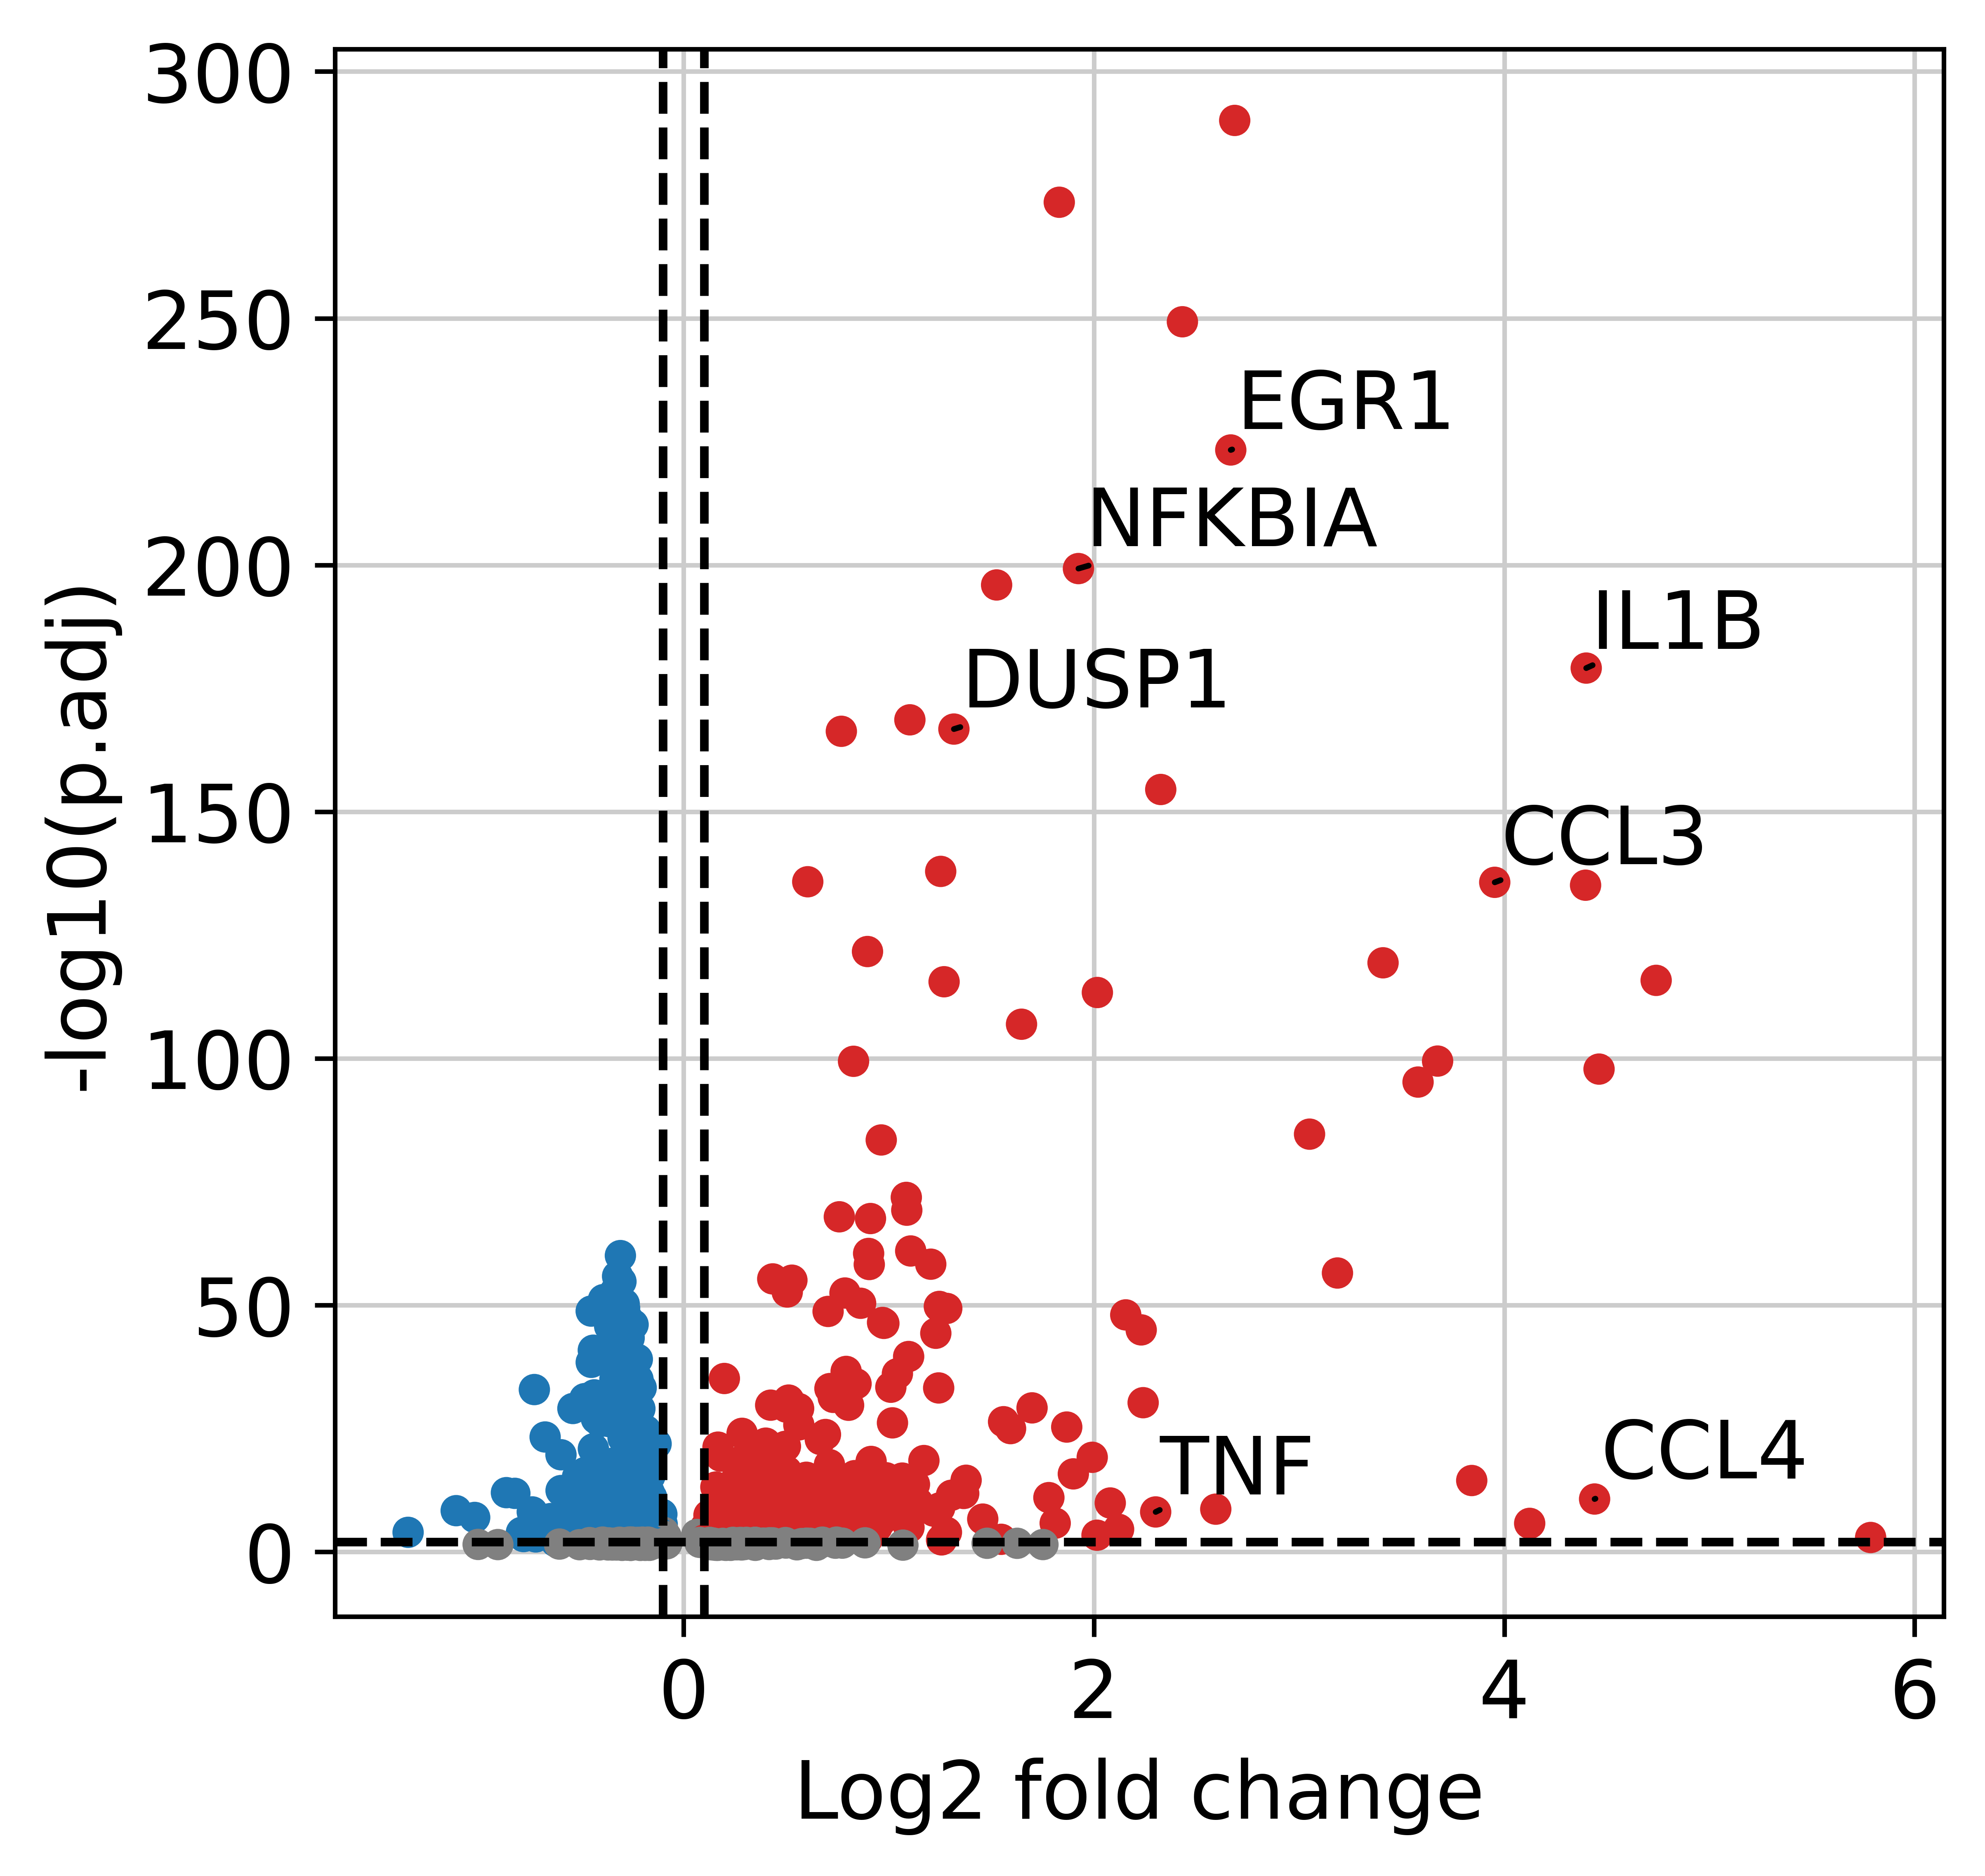

In [28]:
plot_volcano_df(
    il1bvscore_cd14_degs,
    x="logfoldchanges",
    y="pvals_adj",
    genes=['IL1B', 'CCL3', 'CCL4', 'NFKBIA', 'DUSP1', 'EGR1', 'NFKB1A', 'TNF'],
    lFCs_thr=0.1,
    sign_thr=0.01,
    figsize=(5, 5),
    dpi=500,
    save=fig_path + proj_name + cluster_name + "_il1bvscore_cd14_degs_valcano.pdf",
)

### Fig 2H compare the il1b monocytes with the tissue macrophage genes
- referenece geneset downloaded from Alivernini et al https://www.nature.com/articles/s41591-020-0939-8

In [29]:
# load the degs table
macrophage_degs = pd.read_excel(
    "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/reference_data/Alivernini_et_al_tissue_Macrophage"
    + "/41591_2020_939_MOESM3_ESM_cluster_degs.xlsx"
)
# take cluster 8
cluster_degs_c8 = macrophage_degs.loc[macrophage_degs["cluster"] == 8]
cluster_degs_c8

,rank,P-value,average log foldchange,pct of cluster,pct of rest,adjusted P-value,cluster,gene symbol,multi test corrected P-value
1941,1942,0.000000e+00,2.148535,0.788,0.225,0.000000e+00,8,CCL4,0.000000e+00
1942,1943,0.000000e+00,2.114161,0.651,0.155,0.000000e+00,8,CCL3L3,0.000000e+00
1943,1944,0.000000e+00,2.068776,0.920,0.425,0.000000e+00,8,CCL3,0.000000e+00
1944,1945,0.000000e+00,1.944388,0.652,0.170,0.000000e+00,8,IL1B,0.000000e+00
1945,1946,3.746088e-293,1.816285,0.637,0.165,7.715444e-289,8,CCL4L2,6.943899e-288
...,...,...,...,...,...,...,...,...,...
1997,1998,6.449070e-16,-0.287750,0.414,0.529,1.328250e-11,8,IFI30,1.195425e-10
1998,1999,1.426805e-10,-0.293433,0.925,0.928,2.938647e-06,8,LYZ,2.644782e-05
1999,2000,1.973470e-08,-0.293575,0.461,0.498,4.064558e-04,8,CREM,3.658102e-03
2000,2001,2.859686e-15,-0.297673,0.443,0.538,5.889809e-11,8,MNDA,5.300828e-10


<Axes: >

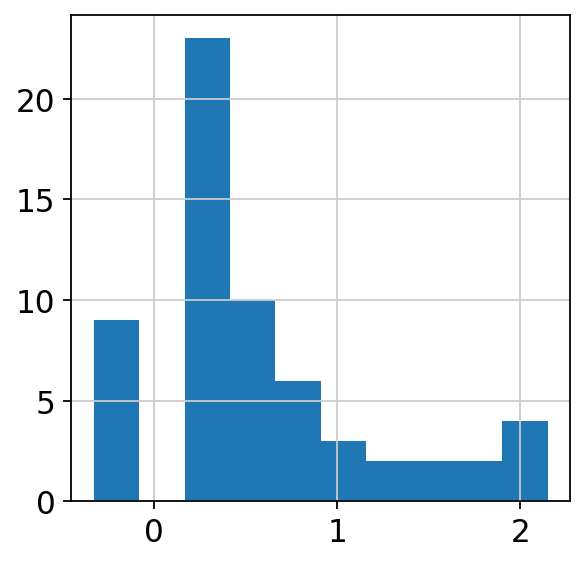

In [30]:
cluster_degs_c8["average log foldchange"].hist()

In [31]:
c8_degs = cluster_degs_c8.loc[
    cluster_degs_c8["average log foldchange"] > 0, "gene symbol"
]
len(c8_degs)

52

In [33]:
# create a C8 scores
sc.tl.score_genes(pair_mono_adata, c8_degs, score_name="c8_score")

TypeError: unsupported operand type(s) for /: '_CSRDataset' and 'int'

In [ ]:
pair_mono_adata.obs[
    [
        "c8_score",
        "AIFI_L3_new",
        "sample.sampleKitGuid",
        "subject.subjectGuid",
        "subject.biologicalSex",
        "status",
    ]
].to_csv(output_path + "ALTRA_mono_C8_scores.csv")

In [ ]:
output_path + "ALTRA_mono_C8_scores.csv"

In [ ]:
sns.set_style("ticks")
with plt.rc_context({"figure.figsize": (4, 4)}):
    sc.pl.violin(
        pair_mono_adata,
        ["c8_score"],
        groupby="AIFI_L3_new",
        rotation=90,
        stripplot=False,  # remove the internal dots
        inner="box",  # adds a boxplot inside violins
        save=proj_name + "C8_AIFI_L3_score.pdf",
    )
# sc.pl.violin(pair_mono_adata, 'c8_score', stripplot=False, groupby='AIFI_L3_new')

In [ ]:
pair_mono_sub = pair_mono_adata[
    :, pair_mono_adata.var.index.isin(macrophage_degs["gene symbol"])
].copy()
pair_mono_sub

In [ ]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca
sc.pp.pca(pair_mono_sub, svd_solver="arpack")
# plot the principle component variance explained
sc.pl.pca_variance_ratio(pair_mono_sub, log=True)

In [ ]:
pair_mono_sub

In [ ]:
sc.pp.neighbors(pair_mono_sub, n_neighbors=10, n_pcs=5)
sc.tl.umap(pair_mono_sub)

In [ ]:
# sc.pp.neighbors(mono_adata, n_neighbors=10, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.tsne(pair_mono_sub)

In [ ]:
sc.pl.embedding(
    pair_mono_sub,
    palette="tab10",
    color=["AIFI_L3_new"],
    legend_loc="on data",
    size=6,
    basis="X_tsne",
    frameon=False,
    save=proj_name + "_AIFI_L3_new.pdf",
)

In [ ]:
sc.pl.umap(pair_mono_sub, color=["AIFI_L3"], size=6, save=proj_name + "_rna_umap.png")

In [ ]:
# take marker genes for c8
c8_genes = cluster_degs_c8["gene symbol"][0:10][
    cluster_degs_c8["gene symbol"][0:10].isin(pair_mono_adata.var.index)
]
c8_genes

In [ ]:
gene_list = [
    "CD14",
    "FCGR3A",
    "HLA-DRA",
    "CCR2",
    "IL1B",
    "TNF",
    "CCL3",
    "CCL4",
    "CXCL3",
    "CXCL8",
    "ICAM1",
    "NFKBIA",
    "NLRP3",
    "KLF6",
    "NR4A1",
    "DUSP1",
]
cm = 1 / 2.54  # centimeters in inches

dp = sc.pl.dotplot(
    pair_mono_adata,
    gene_list,
    "AIFI_L3",
    standard_scale="var",
    figsize=[10.73 / 1.2, 3.21 / 1.2],
    #  return_fig=True,
    save=proj_name + "_paired_samples_AIFI_L3.pdf",
    dendrogram=False,
)

In [ ]:
gene_list = pd.Series(
    [
        "CD14",
        "FCGR3A",
        "HLA-DRA",
        "CCR2",
        "IL1B",
        "TNF",
        "CCL3",
        "CCL4",
        "CXCL3",
        "CXCL8",
        "CXCL10",
        "ICAM1",
        "NFKBIA",
        "NLRP3",
        "KLF6",
        "NR4A1",
        "DUSP1",
    ]
)
gene_list[~gene_list.isin(c8_degs)]

In [ ]:
# Create the dotplot and return the figure
sc.pl.dotplot(pair_mono_adata, c8_genes, groupby="AIFI_L3", standard_scale="var")

## extract frequency by L3

In [ ]:
# extract the frequency out of the monocytes
cluster_name = "AIFI_L3_new"
cell_counts = (
    pair_mono_adata.obs.groupby(["sample.sampleKitGuid", cluster_name])
    .size()
    .reset_index(name="counts")
    .rename({cluster_name: "cell_type"}, axis=1)
)
meta_keep = pair_mono_adata.obs.loc[
    :,
    [
        "sample.sampleKitGuid",
        "subject.subjectGuid",
        "subject.biologicalSex",
        "status",
        "file.batchID",
    ],
].drop_duplicates()
total_mono_counts = (
    pair_mono_adata.obs.groupby(["sample.sampleKitGuid"])
    .size()
    .reset_index(name="total_mono_counts")
)
mono_freq = cell_counts.merge(meta_keep, how="left", on=["sample.sampleKitGuid"]).merge(
    total_mono_counts, how="left", on=["sample.sampleKitGuid"]
)
mono_freq["mono_frequency"] = mono_freq["counts"] / mono_freq["total_mono_counts"]
mono_freq

In [ ]:
mono_freq.to_csv(
    output_path + proj_name + "paired_mono_" + cluster_name + "_frequency.csv"
)

In [ ]:
output_path + proj_name + "paired_mono_" + cluster_name + "_frequency.csv"

## subset the cd16 monocytes

In [ ]:
mono_adata.obs["pred_manual"].unique()

In [ ]:
cd16_mono = mono_adata[
    (mono_adata.obs["pred_manual"].str.contains("CD16|Int|IL1B"))
].copy()
cd16_mono

In [ ]:
# save the dataset
cd16_mono.write_h5ad(data_path + "ALTRA_scRNA_CD16_monocytes.h5ad")

# Session Info

In [ ]:
import sinfo

sinfo.sinfo(write_req_file=False)